In [ ]:
import pandas as pd
from tensorflow import keras
import tensorflow as tf
import numpy as np
import os
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from keras.optimizers import Adam
   

In [2]:
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'

In [3]:
df=pd.read_csv("cleaned_dataset_taiwan_2months.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125914 entries, 0 to 125913
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   date      125914 non-null  object 
 1   sitename  125914 non-null  object 
 2   county    125914 non-null  object 
 3   aqi       125914 non-null  float64
 4   status    125914 non-null  object 
 5   so2       125914 non-null  float64
 6   co        125914 non-null  float64
 7   o3        125914 non-null  float64
 8   pm10      125914 non-null  float64
 9   pm2.5     125914 non-null  float64
 10  no2       125914 non-null  float64
 11  nox       125914 non-null  float64
 12  no        125914 non-null  float64
 13  siteid    125914 non-null  int64  
dtypes: float64(9), int64(1), object(4)
memory usage: 13.4+ MB


In [4]:
to_numeric_column=["aqi",'so2','co','o3','pm2.5','pm10','no2','nox','no','siteid']
df[to_numeric_column]=df[to_numeric_column].apply(pd.to_numeric, errors='coerce')
df[to_numeric_column] = df[to_numeric_column].ffill().bfill()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125914 entries, 0 to 125913
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   date      125914 non-null  object 
 1   sitename  125914 non-null  object 
 2   county    125914 non-null  object 
 3   aqi       125914 non-null  float64
 4   status    125914 non-null  object 
 5   so2       125914 non-null  float64
 6   co        125914 non-null  float64
 7   o3        125914 non-null  float64
 8   pm10      125914 non-null  float64
 9   pm2.5     125914 non-null  float64
 10  no2       125914 non-null  float64
 11  nox       125914 non-null  float64
 12  no        125914 non-null  float64
 13  siteid    125914 non-null  int64  
dtypes: float64(9), int64(1), object(4)
memory usage: 13.4+ MB


In [5]:
df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
0,2024-08-31 23:00:00,Hukou,Hsinchu County,62.0,Moderate,0.9,0.17,35.0,18.0,17.0,2.3,2.6,0.3,22
1,2024-08-31 23:00:00,Zhongming,Taichung City,50.0,Good,1.6,0.32,27.9,27.0,14.0,7.6,9.3,1.6,31
2,2024-08-31 23:00:00,Zhudong,Hsinchu County,45.0,Good,0.4,0.17,25.1,21.0,13.0,2.9,4.1,1.1,23
3,2024-08-31 23:00:00,Hsinchu,Hsinchu City,42.0,Good,0.8,0.20,30.0,19.0,10.0,4.0,4.8,0.7,24
4,2024-08-31 23:00:00,Toufen,Miaoli County,50.0,Good,1.0,0.16,33.5,18.0,14.0,1.8,3.1,1.2,25


In [6]:
def model_train(input_shape):
    model=keras.models.Sequential()

    model.add(keras.layers.Input(shape=input_shape))
    model.add(keras.layers.LSTM(100,return_sequences=True))
    model.add(keras.layers.Dropout(0.5))
    
    model.add(keras.layers.LSTM(100,return_sequences=False))
    model.add(keras.layers.Dropout(0.2))
    
    model.add(keras.layers.Dense(32,activation="relu"))
    model.add(keras.layers.Dense(1))
    

    return model

In [ ]:
n_windows=100
scaler=MinMaxScaler(feature_range=(0,1))

feature=df[["aqi",'so2','co','o3','pm2.5','pm10','no2','nox','no']]
dataset=feature.values  
training_dataset_len=int(np.ceil(len(dataset)*0.90))
if len(dataset.shape) == 1:
    dataset = dataset.reshape(-1, 1)

print(dataset.shape)

(125914, 9)


In [8]:
scaled_data=scaler.fit_transform(dataset)
training_data=scaled_data[:training_dataset_len:]
X_train,y_train=[],[]

for i in range(n_windows,len(training_data)):
    X_train.append(training_data[i-n_windows:i:])
    y_train.append(training_data[i,0])

X_train, y_train=np.array(X_train),np.array(y_train)

model = model_train(input_shape=(X_train.shape[1], X_train.shape[2]))

In [9]:
model.compile(optimizer=Adam(learning_rate=0.0005),
             loss="mae",  #mae
             metrics=[keras.metrics.RootMeanSquaredError()])

model.fit(X_train, y_train, epochs=10, batch_size=32, shuffle=True,verbose=1)

Epoch 1/10
3539/3539 ━━━━━━━━━━━━━━━━━━━━ 323s 90ms/step - loss: 0.0550 - root_mean_squared_error: 0.0763
Epoch 2/10
3539/3539 ━━━━━━━━━━━━━━━━━━━━ 293s 83ms/step - loss: 0.0534 - root_mean_squared_error: 0.0743
Epoch 3/10
3539/3539 ━━━━━━━━━━━━━━━━━━━━ 296s 84ms/step - loss: 0.0531 - root_mean_squared_error: 0.0739
Epoch 4/10
3539/3539 ━━━━━━━━━━━━━━━━━━━━ 363s 103ms/step - loss: 0.0529 - root_mean_squared_error: 0.0737
Epoch 5/10
3539/3539 ━━━━━━━━━━━━━━━━━━━━ 371s 105ms/step - loss: 0.0527 - root_mean_squared_error: 0.0735
Epoch 6/10
3539/3539 ━━━━━━━━━━━━━━━━━━━━ 330s 93ms/step - loss: 0.0525 - root_mean_squared_error: 0.0733
Epoch 7/10
3539/3539 ━━━━━━━━━━━━━━━━━━━━ 305s 86ms/step - loss: 0.0524 - root_mean_squared_error: 0.0731
Epoch 8/10
3539/3539 ━━━━━━━━━━━━━━━━━━━━ 311s 88ms/step - loss: 0.0522 - root_mean_squared_error: 0.0729
Epoch 9/10
3539/3539 ━━━━━━━━━━━━━━━━━━━━ 299s 85ms/step - loss: 0.0521 - root_mean_squared_error: 0.0728
Epoch 10/10
3539/3539 ━━━━━━━━━━━━━━━━━━━━ 3

In [11]:
model.save("model_trained.keras")

In [12]:
# 1. Prepare the full test set
test_data_scaled = scaled_data[training_dataset_len - n_windows:]

X_test_all, y_test_all = [], []
for i in range(n_windows, len(test_data_scaled)):
    X_test_all.append(test_data_scaled[i-n_windows:i, :])
    # Use the original unscaled dataset for ground truth comparison
    y_test_all.append(dataset[training_dataset_len + (i - n_windows), 0]) 

X_test_all = np.array(X_test_all)
y_test_all = np.array(y_test_all)

# 2. Generate Predictions
predictions_scaled = model.predict(X_test_all, verbose=0)

# 3. Inverse Scale the Predictions
# Based on your notebook, your scaler was fit on 9 features
dummy = np.zeros((len(predictions_scaled), 9))
dummy[:, 0] = predictions_scaled.flatten()
predictions_all = scaler.inverse_transform(dummy)[:, 0]

In [17]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_score, recall_score
import numpy as np

# Define thresholds based on your Taiwan monitoring standards
# 0-50, 51-100, 101-150, 151-200
bins = [0, 50, 100, 150, 200]
labels = ["Good", "Moderate", "Unhealthy (Sensitive)", "Unhealthy"]

def categorize_data(data):
    # np.digitize returns the index of the bin the value falls into
    # We use clip to ensure values above 200 stay in the highest category
    indices = np.digitize(data, bins) - 1
    indices = np.clip(indices, 0, len(labels) - 1)
    return np.array([labels[i] for i in indices])

# Convert continuous values to categorical labels
y_test_cat = categorize_data(y_test_all)
predictions_cat = categorize_data(predictions_all)

In [18]:
accuracy = accuracy_score(y_test_cat, predictions_cat)
precision = precision_score(y_test_cat, predictions_cat, average='weighted')
recall = recall_score(y_test_cat, predictions_cat, average='weighted')
f1 = f1_score(y_test_cat, predictions_cat, average='weighted')

print("--- Overall Categorical Performance (Global) ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Optional: Print the full report for per-category details
print("\nDetailed Classification Report:")
print(classification_report(y_test_cat, predictions_cat))

--- Overall Categorical Performance (Global) ---
Accuracy:  97.44%
Precision: 0.9656
Recall:    0.9744
F1-Score:  0.9624

Detailed Classification Report:
                       precision    recall  f1-score   support

                 Good       0.97      1.00      0.99     12267
             Moderate       0.62      0.02      0.03       323
Unhealthy (Sensitive)       0.00      0.00      0.00         1

             accuracy                           0.97     12591
            macro avg       0.53      0.34      0.34     12591
         weighted avg       0.97      0.97      0.96     12591



c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Adminis

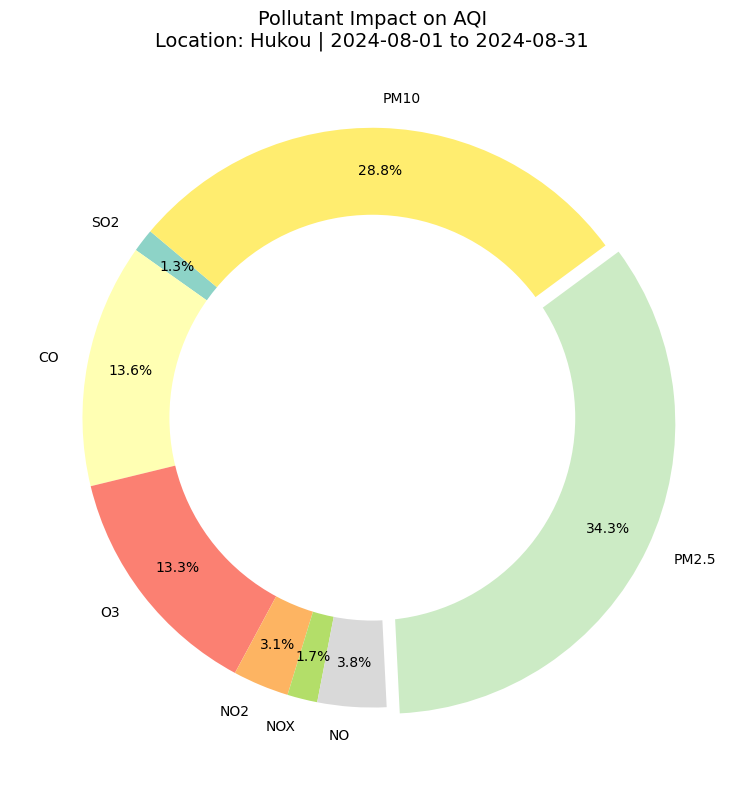

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_pollutant_impact_pie(df, site_name, start_date, end_date):
    # 1. Ensure date column is in datetime format
    df['date'] = pd.to_datetime(df['date'])
    
    # 2. Filter data by site and date range
    mask = (df['sitename'] == site_name) & (df['date'] >= start_date) & (df['date'] <= end_date)
    filtered_df = df.loc[mask].copy()
    
    if filtered_df.empty:
        print(f"No data found for site '{site_name}' between {start_date} and {end_date}.")
        return

    # 3. Clean numeric columns for the specific subset
    pollutants = ['so2', 'co', 'o3', 'no2', 'nox', 'no','pm2.5','pm10']
    cols_to_process = pollutants + ['aqi']
    
    for col in cols_to_process:
        filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')
    
    # Fill NaNs specifically for this site to ensure correlations are accurate
    filtered_df[cols_to_process] = filtered_df[cols_to_process].ffill().bfill()

    # 4. Calculate Absolute Correlation as "Impact"
    # This matches the relationships seen in your heatmap
    correlations = filtered_df[pollutants].corrwith(filtered_df['aqi']).abs()
    
    if correlations.isnull().all():
        print("Not enough variation in data to calculate impact for this period.")
        return

    # 5. Generate the Pie Chart
    plt.figure(figsize=(10, 8))
    colors = plt.cm.Set3(np.linspace(0, 1, len(pollutants)))
    
    plt.pie(correlations, 
            labels=[p.upper() for p in pollutants], 
            autopct='%1.1f%%', 
            startangle=140, 
            colors=colors,
            pctdistance=0.85,
            explode=[0.05 if x == correlations.max() else 0 for x in correlations])

    # Draw a circle at the center to make it a donut chart (optional, looks cleaner)
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title(f'Pollutant Impact on AQI\nLocation: {site_name} | {start_date} to {end_date}', fontsize=14)
    plt.tight_layout()
    plt.show()

# --- INPUT YOUR SELECTION HERE ---
target_place = "Hukou"      # Options: Hukou, Zhongming, Zhudong, Hsinchu, Toufen, etc.
start = "2024-08-01"
end = "2024-08-31"

plot_pollutant_impact_pie(df, target_place, start, end)

In [ ]:
model.save("final_model_lstm.keras")